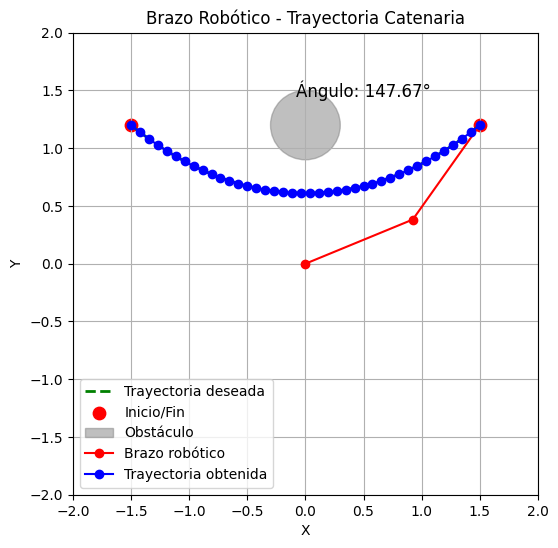

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Parámetros del brazo robótico
L1, L2 = 1.0, 1.0  # Longitudes de los dos eslabones del brazo
T = 40  # Número de puntos de la trayectoria

# Puntos inicial y final de la trayectoria
x_ini, x_fin = -1.5, 1.5  # Coordenadas iniciales y finales de la trayectoria
y_ini = y_fin = 1.2  # Coordenadas y inicial y final

# Obstáculo circular (ubicación y radio)
obstaculo_centro = (0.0, 1.2)
obstaculo_radio = 0.3

# Generación de la trayectoria deseada (catenaria invertida)
x_deseado = np.linspace(x_ini, x_fin, T)  # Genera una secuencia de T puntos entre x_ini y x_fin
a = 2  # Parámetro que controla la curvatura de la catenaria
x0 = 0.0  # Centro simétrico de la catenaria

# Fórmula para la catenaria invertida, centrada en x0 con los extremos en y=1.2
y_deseado = a * (np.cosh((x_deseado - x0) / a) - np.cosh((x_ini - x0) / a)) + 1.2

# Función de cinemática directa: Calcula las posiciones del codo y la punta del brazo dados los ángulos
def forward_kinematics(theta1, theta2):
    # Cálculo de la posición del codo (x1, y1)
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    
    # Cálculo de la posición de la punta (x2, y2)
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    
    return (x1, y1), (x2, y2)

# Función de cinemática inversa: Calcula los ángulos theta1 y theta2 dados los puntos x, y
def inverse_kinematics(x, y, change_codo=False):
    # Ley de cosenos para calcular el segundo ángulo (theta2)
    r = np.sqrt(x**2 + y**2)  # Distancia total desde el origen
    cos_theta2 = (r**2 - L1**2 - L2**2) / (2 * L1 * L2)
    theta2 = np.arccos(np.clip(cos_theta2, -1, 1))  # Asegura que el valor esté en el rango válido [-1, 1]

    # Si el ángulo del codo debe cambiar (a mitad de la trayectoria), forzamos un cambio en el signo de theta2
    if not change_codo:
        theta2 = -theta2  # Cambiar el codo hacia la izquierda

    # Ángulo para el primer brazo (theta1), calculado usando el ángulo del segundo brazo (theta2)
    theta1 = np.arctan2(y, x) - np.arctan2(L2 * np.sin(theta2), L1 + L2 * np.cos(theta2))
    return theta1, theta2

# Cálculo de los ángulos para cada punto de la trayectoria deseada
theta1_opt, theta2_opt = [], []  # Listas para almacenar los ángulos calculados
for i in range(T):
    # Cambiar el ángulo del codo después de la mitad de la trayectoria
    change_codo = i > T // 2  # Cambiar el signo del ángulo del codo a mitad de trayectoria
    theta1, theta2 = inverse_kinematics(x_deseado[i], y_deseado[i], change_codo)
    theta1_opt.append(theta1)  # Guardar theta1 en la lista
    theta2_opt.append(theta2)  # Guardar theta2 en la lista

# Crear la figura para la visualización
fig, ax = plt.subplots(figsize=(6, 6))  # Crear una figura y un conjunto de ejes
ax.set_xlim(-2, 2)  # Límites del eje X
ax.set_ylim(-2, 2)  # Límites del eje Y
ax.set_xlabel("X")  # Etiqueta del eje X
ax.set_ylabel("Y")  # Etiqueta del eje Y
ax.set_title("Brazo Robótico - Trayectoria Catenaria")  # Título de la gráfica
ax.grid(True)  # Mostrar la cuadrícula

# Traza de la trayectoria deseada en verde
ax.plot(x_deseado, y_deseado, 'g--', label="Trayectoria deseada", linewidth=2)

# Puntos de inicio y fin de la trayectoria
ax.scatter([x_deseado[0], x_deseado[-1]], [y_deseado[0], y_deseado[-1]], 
           color='red', marker='o', s=80, label="Inicio/Fin")

# Obstáculo circular representado como un círculo gris
obstaculo = plt.Circle(obstaculo_centro, obstaculo_radio, color='gray', alpha=0.5, label="Obstáculo")
ax.add_patch(obstaculo)

# Inicialización del brazo y la trayectoria obtenida en la gráfica
brazo, = ax.plot([], [], 'ro-', markersize=6, label="Brazo robótico")  # Brazo robótico representado por círculos rojos
trayectoria_obtenida, = ax.plot([], [], 'bo-', label="Trayectoria obtenida")  # Trayectoria obtenida del brazo
angulo_texto = ax.text(0.5, 1.5, "", fontsize=12, ha='center', va='center', color='black')  # Texto para mostrar el ángulo

# Función de actualización para cada fotograma de la animación
def actualizar(i):
    codo, punta = forward_kinematics(theta1_opt[i], theta2_opt[i])  # Obtener las posiciones del codo y la punta
    brazo.set_data([0, codo[0], punta[0]], [0, codo[1], punta[1]])  # Actualizar las posiciones del brazo
    puntas_opt = np.array([forward_kinematics(theta1_opt[j], theta2_opt[j])[1] for j in range(i+1)])  # Obtener todas las posiciones de las puntas hasta el fotograma i
    trayectoria_obtenida.set_data(puntas_opt[:, 0], puntas_opt[:, 1])  # Dibujar la trayectoria obtenida
    angulo = abs(theta2_opt[i])  # Calcular el ángulo en el segundo eslabón
    angulo_grados = 180 - np.degrees(angulo)  # Convertir el ángulo a grados
    angulo_texto.set_text(f"Ángulo: {angulo_grados:.2f}°")  # Mostrar el ángulo en el gráfico
    return brazo, trayectoria_obtenida, angulo_texto  # Devolver los objetos que se actualizan

# Animación: Función que actualiza la visualización para cada fotograma
ani = animation.FuncAnimation(fig, actualizar, frames=T, interval=200, blit=True)

# Mostrar leyenda
plt.legend()

# Mostrar la animación en Jupyter Notebook
HTML(ani.to_jshtml())


Descripción de las funciones:
forward_kinematics(theta1, theta2): Calcula las posiciones del codo y la punta del brazo dado un par de ángulos theta1 y theta2. Usa la geometría del brazo robótico para calcular las coordenadas de los puntos en el espacio 2D.

inverse_kinematics(x, y, change_codo=False): Calcula los ángulos theta1 y theta2 necesarios para alcanzar un punto (x, y) en el espacio. Utiliza la ley de cosenos para calcular theta2 y una corrección geométrica para theta1.

actualizar(i): Función que actualiza la visualización de la animación para cada fotograma. Calcula las posiciones del brazo robótico y la trayectoria obtenida en cada paso de la animación, actualizando tanto la posición del brazo como la trayectoria trazada en el gráfico.

Explicación de la animación:
Trayectoria Deseada: El brazo debe seguir una trayectoria catenaria generada por la fórmula de la catenaria invertida.

Cambio de Codo: Después de la mitad de la trayectoria, el codo cambia de dirección para evitar que el brazo choque con el obstáculo circular. Este cambio se maneja a través del parámetro change_codo en la función inverse_kinematics.

¿Qué hace el código?
Generación de la trayectoria: Se crea una trayectoria catenaria invertida entre los puntos de inicio y fin.

Cinemática inversa: Calcula los ángulos necesarios para seguir cada punto de la trayectoria.

Animación: Muestra el brazo robótico moviéndose a través de la trayectoria y ajustando el codo cuando es necesario para evitar el obstáculo.